In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
import torch
import re
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
    print("✅ GPU kullanılıyor")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("⚠️ GPU yok, CPU kullanılıyor")

✅ GPU kullanılıyor
GPU: Tesla T4


In [ ]:
df = pd.read_csv("articles_clean.csv")
df.head()

,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


In [ ]:
df["combined_text"].iloc[0]

'i̇nsansız hava araçları için manyetik rezonans kuplaj ile şarj i̇stasyonu tasarımı i̇nsansız hava araçları (i̇ha) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. gerçekleştirilen bu çalışmada, i̇ha’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. devre tasarımlarının analizleri, matlab ve pspice programları sayesinde gerçekleştirilmiştir. ayrıca; şarj cihazında kullanılan bobinler, ansys maxwell programı kullanılarak tasarlanmıştır. tasarlanan şarj istasyonu ile 12 cm’den 3w gücündeki lityum bataryalar şarj edilmiştir. tasarlanan sistem ile i̇ha’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır. insansız hava aracı (i̇ha), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.'

In [ ]:
df.isnull().sum()

,0
Year,0
Title_TR,0
Abstract_TR,0
Keywords_TR,0
title_tr_clean,0
abstract_tr_clean,0
keywords_tr_clean,0
combined_text,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               666 non-null    object
 1   Title_TR           666 non-null    object
 2   Abstract_TR        666 non-null    object
 3   Keywords_TR        666 non-null    object
 4   title_tr_clean     666 non-null    object
 5   abstract_tr_clean  666 non-null    object
 6   keywords_tr_clean  666 non-null    object
 7   combined_text      666 non-null    object
dtypes: object(8)
memory usage: 41.8+ KB


In [ ]:
target = df["combined_text"]
target.head()

,combined_text
0,i̇nsansız hava araçları için manyetik rezonans...
1,i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,hava muharebesinde otonom savunma algoritmasın...
3,"modernization projects bu makalede, türk havac..."
4,döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


### SBERT (Sentence-BERT) – Türkçe Spesifik Model

Bu çalışmada, Türkçe metinler arasındaki anlamsal benzerliği daha hassas ölçmek amacıyla **SBERT mimarisi** kullanılmıştır.  
Model, Hugging Face üzerinde **`emrecan/bert-base-turkish-cased-mean-nli-stsb-tr`** adıyla yayınlanmıştır.

**Temel Özellikler:**
- 🇹🇷 **Türkçe Odaklı:** Çok dilli modellere kıyasla doğrudan Türkçe STS (Semantic Textual Similarity) ve NLI veri setleriyle eğitilmiştir.  
- 🧠 **Yüksek Çözünürlük:** 768 boyutlu embedding’ler üreterek teknik ve akademik metinlerdeki ince anlam farklarını yakalayabilir.  
- 📐 **STS-B Uyumu:** Türkçe semantik benzerlik görevlerinde yüksek korelasyon başarımı gösterir.

**BERTurk’ten Farkı:**
- BERTurk genel amaçlı bağlamsal temsil üretirken, SBERT doğrudan **cümle/metin benzerliği** için optimize edilmiştir.  
- Alakasız metinlerin yüksek benzerlik alması gibi problemlerin (anisotropy) etkisini azaltır.

**Kullanım Alanları:**
- Semantik arama (Semantic Search)  
- Proje / doküman örtüşme tespiti  
- Otomatik metin eşleştirme

In [ ]:
model_name = "emrecan/bert-base-turkish-cased-mean-nli-stsb-tr"
model = SentenceTransformer(model_name, device=device)

print(f"✅ Model loaded: {model_name}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded: emrecan/bert-base-turkish-cased-mean-nli-stsb-tr


Token indices sequence length is longer than the specified maximum sequence length for this model (168 > 75). Running this sequence through the model will result in indexing errors


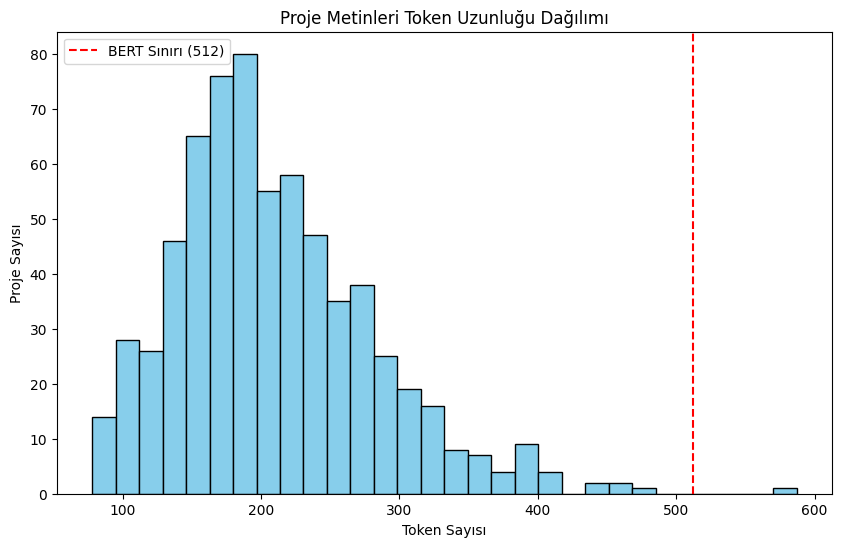

Ortalama token sayısı: 208.93843843843842
512 token'ı geçen proje sayısı: 1


In [ ]:
# Her projenin metin uzunluğunu 'token' bazında hesaplar
df['token_counts'] = df['combined_text'].apply(lambda x: len(model.tokenizer.encode(x)))

# Token dağılımını görselleştirir ve 512 sınırını işaretler
plt.figure(figsize=(10, 6))
plt.hist(df['token_counts'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=512, color='red', linestyle='--', label='BERT Sınırı (512)')
plt.title('Proje Metinleri Token Uzunluğu Dağılımı')
plt.xlabel('Token Sayısı')
plt.ylabel('Proje Sayısı')
plt.legend()
plt.show()

# Ortalama uzunluk ve sınırı aşan proje sayısını yazdırır
print(f"Ortalama token sayısı: {df['token_counts'].mean()}")
print(f"512 token'ı geçen proje sayısı: {(df['token_counts'] > 512).sum()}")

In [ ]:
# Pandas için ilerleme çubuğu
tqdm.pandas()
print("🚀 Embedding üretimi başladı...")

# Tüm metinleri vektöre çevirir
df["embedding"] = df["combined_text"].progress_apply(
    lambda x: model.encode(
        str(x),
        convert_to_numpy=True,
        normalize_embeddings=True
    ).tolist()
)

print("\n✅ Embedding işlemi tamamlandı")
print("Toplam kayıt:", len(df))
print("Vektör boyutu:", len(df["embedding"].iloc[0]))

🚀 Embedding üretimi başladı...


100%|██████████| 666/666 [00:07<00:00, 86.58it/s]


✅ Embedding işlemi tamamlandı
Toplam kayıt: 666
Vektör boyutu: 768


In [ ]:
# Metin Temizleme
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[#%&*_=+<>]", "", text)
    return text.strip()

raw_query_title = "Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi"

raw_query_abstract = (
    "Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak "
    "birebir muharebeler için otonom savunma algoritması geliştirilmiştir. "
    "Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda "
    "saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. "
    "Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan "
    "dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş "
    "manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı "
    "bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile "
    "algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir."
)

raw_query_keywords = (
    "bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları"
)

In [ ]:
query_text = " ".join([
    clean_text(raw_query_title),
    clean_text(raw_query_abstract),
    clean_text(raw_query_keywords)
])

# Vektöre çevirme
query_vector = model.encode(
    query_text,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float32)

# Tüm embeddingleri tek bir numpy matrisine topluyoruz
corpus_embeddings = np.array(df["embedding"].tolist(), dtype=np.float32)

# Kosinüs benzerliğini hesaplama
similarity_scores = util.cos_sim(
    query_vector,
    corpus_embeddings
)[0]

# Raporlama
df["similarity_score"] = similarity_scores.cpu().numpy()
top_results = df.sort_values(by="similarity_score", ascending=False)

print("🔍 En Benzer 5 Sonuç")
with pd.option_context('display.max_colwidth', None):
  display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].head(5))

print("\n")

print("❌ En Alakasız 5 Sonuç")
with pd.option_context('display.max_colwidth', None):
  display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].tail(5))

🔍 En Benzer 5 Sonuç


,Year,Title_TR,Abstract_TR,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi,"Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir.",1.000000
478,2023-2024,Hava Muharebesinde Bulanık Mantık ile Karar,"Hava muharebeleri, saldırı ve savunma manevralarının dengeli bir şekilde yapıldığı karmaşık stratejilere dayanmaktadır. Bu projede, hava muharebelerinde otonom karar alma yeteneğini artırmak için oyun teorisi, bulanık mantık ve dinamik programlama gibi ileri düzey tekniklerin birleşiminden oluşan bir algoritma geliştirilmesi hedeflenmektedir. Geliştirilecek olan algoritma, hava muharebelerinde bilinçli kararlar alabilen otonom sistemlerin geliştirilmesine odaklanmaktadır. Bu amaçla, geliştirilen algoritma simülasyon ortamında test edilecek ve başarı oranı ölçülecektir. Algoritmanın performansı, çeşitli simüle edilmiş muharebe senaryoları üzerinde test edilerek değerlendirilecektir. Başarı metrikleri arasında, misyon başarı oranları, kaynak kullanım verimliliği ve değişen ortamlara uygunluk gibi faktörler bulunacaktır. Bu çalışma, hava muharebelerinde otonom sistemlerin karar alma yeteneğini artırmak için kullanılabilecek yeni ve etkili bir yaklaşım sunmayı amaçlamaktadır.",0.784140
479,2023-2024,"Hava Muharebesinde Oyun Teorisi, Bulanık Mantık ve Dinamik Programlama Kullanarak Karar Verme Algoritmasının Uygulanması ve Analizi","Bu çalışmada hava muharebesinde askeri pilotların başarı oranını artırmak için eğitim amaçlı kullanılmak üzere hava araçlarının aerodinamik yapıları göz önünde bulundurularak Unity oyun motorunda simülasyon ortamı hazırlanmıştır. Bu ortamda eğitim görmekte olan pilotlarla yarışacak, düşman pilot olarak görev alacak, pilotların manevralarını analiz ederek sürekli kendi stratejisini belirleyecek bir yapay zekâ modeli geliştirilmiştir. Yapay zekâ modelinin tasarımında derin öğrenme ve takviyeli öğrenme tekniklerini birleştiren Derin Q Ağları (DQN) kullanılmıştır. Bu alanda belirttiğimiz tekniklerle, geliştirdiğimiz eğitim simülasyon ortamının bir araya getirilmesi çalışmamızın temel katkısıdır. Geliştirilen simülasyon sistemi ve DQN tabanlı yapay zekâ modeli, hava muharebesi eğitimlerinde kullanılacak bir eğitim aracının temellerini oluşturmuştur.",0.721700
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar Kullanılarak Karar Verme Algoritmalarının Gerçeklenmesi ve Analizi,"Hava muharebelerinde otonominin giderek yaygın- laşmasıyla birlikte görevleri yüksek başarı oranlarıyla gerçekleş- tirecek uçuş algoritmalarının önemi her geçen gün artmaktadır. Bu çalışmada ise bulanık mantık destekli karar verme algoritma- ları ile otonom hava muharebelerinde meydana gelebilecek du- rumlar için bulanık mantık kural tabanı ile MATLAB kullanıla- rak uçuş senaryolarının simülasyon ortamında gerçeklenmesi amaçlanmıştır. Uçakların it dalaşındaki etkinliği değerlendiril- mektedir. Algoritma, hedef uçak hareketine bağlı olarak bulanık mantık kural tabanına göre uygun referans değerlerini üreterek saldırı manevraları gerçekleştirmektedir.",0.701452
392,2023-2024,AGCAS Algoritması Tasarımı,"AGCAS Otomatik Çarpışma Algılama ve Önleme Sistemi Algoritması, özellikle jet eğitim uçaklarında öğrenci pilotların uçuşları sırasında uçuş güvenliğini arttırmak amacıyla geliştirilmiş bir sistemdir. Bu projede, gerçek dünya yükselti verilerine dayalı bir t



❌ En Alakasız 5 Sonuç


,Year,Title_TR,Abstract_TR,similarity_score
236,2022-2023,Bulanıklık Giderme İşleminin Elektro-Optik Uydu,"Yüksek çözünürlüklü Elektro-Optik uydular coğrafi kısıtlama olmadan Dünya üzerinde herhangi bir noktadan görüntü elde edebilmek için kullanılır. Uydulardan elde edilen görüntülerin netliği (keskinliği) için verilerde bulunan bant genişliğinde istenmeyen bir kayıp dolayısıyla görüntü kalitesindeki düşüş, atmosferik türbülans, uydu üzerindeki sensörlerin davranışı, görüntünün elde edilme sürecinde görüntüleme sistemi ve enstrümantal optiklerin kümülatif etkilerinden ve uydu hareketlerinden dolayı oluşan bozulmaların düzeltilmesi gerekir. Bu çalışmada, bir görüntü işleme sorunu olan Gauss bulanıklığı uygulanarak görüntü üzerindeki etkileri, elektro-optik uydularından elde edilen yüksek çözünürlüklü pankromatik bir verinin bulanıklık giderme işlemini ve bulanıklığı azaltmanın kenar yayma işlevi ve bu işlevden geliştirilen Nokta Yayma !şlevi ve Çizgi Yayma !şlevi yöntemleri kullanarak hesaplanan Modülasyon Transfer Fonksiyonu (MTF) değeri üzerindeki etkileri ele alınmıştır. Ayrıca, Bulanık görüntüleri geri yüklemek için kullanılan Richardson-Lucy Ters Evrişim Algoritması, Düzenlileştirme Filtresi ve Kör Ters Evrişim Algoritmalarının performansı test edilmiş ve algoritmalar karşılaştırılmıştır.",0.227262
503,2023-2024,"İki Eksenli Freze Kafasının Tasarımı, Analizi ve","Bu projeyi yapılmasının ana nedeni, Türkiye'de iki eksenli freze kafasının olmamasıdır. Türkiye, iki eksenli freze başlığı üretmediği için, bu başlıkları Almanya veya Çin gibi başka bir ülkeden ithal etmek zorundadır. Bu cihazları başka bir ülkeden ithal ederken genellikle karşılaşılan sorunlar fiyatlar ve teslimat programlarıdır. Almanya'dan ithal edilen cihazlar genellikle uygun fiyatlı değildir veya uygun fiyatlı olsalar bile, Türkiye'ye ithal edilmeleri çok zaman alır. Bu cihazları ithal ederken ikinci seçenek ise Çin'den satın almaktır. Ancak, bu cihazları Çin'den satın almak genellikle uygun değildir çünkü bu cihazların kalitesi çok düşüktür. Bu cihazlar karmaşık parçaların üretiminde kritik öneme sahiptir, bu yüzden onları sıkça kullanma imkânı olması gereklidir. Önceden belirtilen sorunlar nedeniyle, bu cihaz Türkiye'de tasarlanmalı ve üretilmelidir. Ülkelerin, özellikle savunma sanayinde, bağımsız üretim tesislerine sahip olmaları gerekmektedir. Şu anda, problem açıklaması bölümünde listelenen sorunlar nedeniyle, karmaşık parçalar üretmek zordur çünkü Türkiye iki eksenli freze başlığı üretmemektedir. Bu cihazların ihraç edilmesindeki kritik sorun, başka bir ülkeye bağımlı olmaktır. Bu cihazı üretmek, Türkiye'nin bağımsızlığı için daha iyi olacak ve daha ucuz olacaktır, bu yüzden bu projenin ana motivasyonları bu nedenlerdir.",0.225965
239,2022-2023,Çok Kipli Uydu Görüntülerinden Derin Öğrenme ile Gemi Tespiti,"Deniz yetki alanı ihlalleri, yüzyıllardır birçok devletin milli güvenlik sorunu olmuştur ve birçok savaşa veya diplomatik krize neden olmuştur. Bu bakımdan devletlerin deniz yetki alanlarının güvenliği her zaman için son derece kritik olmuştur. Bunlara ek olarak; gemi trafiğinin takibi, kaçak avcılığın önlenmesi, deniz kirliliğinin önlenmesi ve kayıp gemi/tekne gibi durumlar da her zaman için devletlere büyük yük oluşturmuştur. Bu sorunların ortadan kaldırılması ve deniz yetki alanının güvenliğinin sağlanması için uydu sistemleri kritik rol oynamaktadır. Bu çalışmada, uydu görüntüleri kullanarak gemi tespiti amacıyla derin öğrenme modelleri geliştirilmiş ve performans ölçütleri karşılaştırılmıştır. Çalışmada SSD MobileNet, ResNet ve RCNN gibi popüler derin öğrenme modelleri kullanılmıştır. Bu modeller, yüksek doğruluk ve performans sağlama potansiyeliyle bilinmektedir. Performans değerlendirmesi için ortalama hassasiyet (mAP)ölçütü kullanılmıştır. Bu çalışma, deniz güvenliği ve gemi izleme gibi uygulamalar için yeni bir çözüm sunmaktadır ve gemi tespiti alanındaki araştırmalara değerli bir katkı sağlamaktadır.",0.219628
306,2022-2023,Karışık Sınır 